Script to generate the CHORD survey range plots.

In [1]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt

/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_43482/1248310697.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


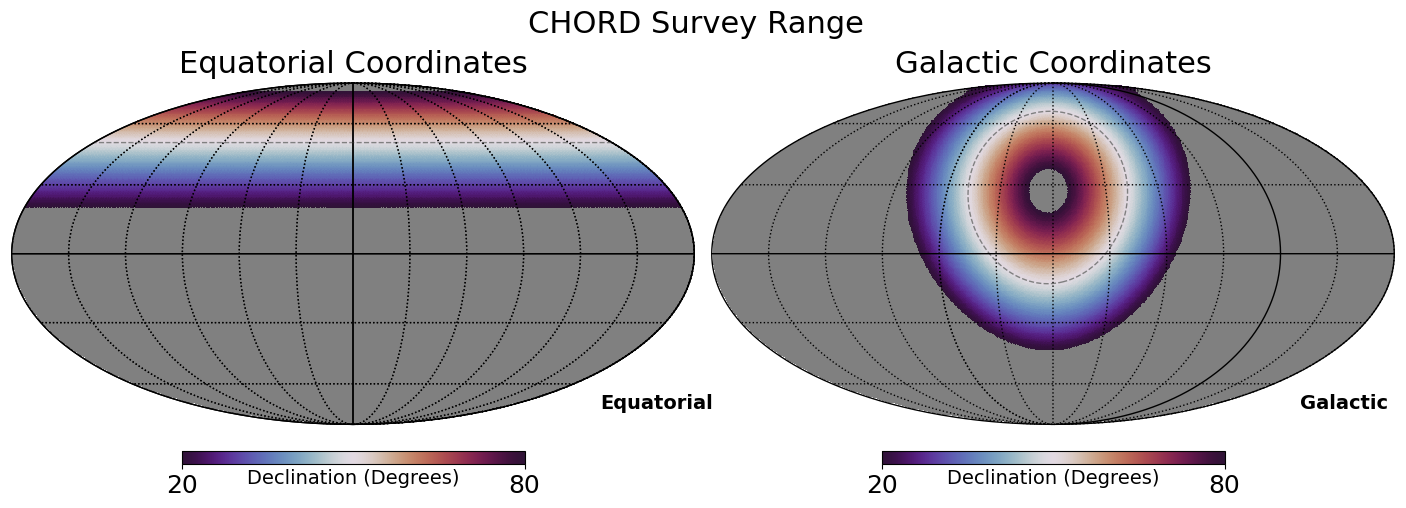

In [20]:
nside = 128
CHORD_angles = np.linspace(20, 80, 100)        # pointing declinations (deg N)
dec = 50                                        
phi = np.linspace(0, 2 * np.pi, 10000)         # dense azimuthal sampling

# --- Build a HEALPix map of CHORD's survey range ---
# For each candidate pointing declination, the instantaneous beam traces a
# constant-colatitude arc on the sky. We rasterize every arc and keep, per
# pixel, the lowest declination that reaches it.
nside = 128
CHORD_angles = np.linspace(20, 80, 100)        # pointing declinations (deg N)
phi = np.linspace(0, 2 * np.pi, 10000)         # dense azimuthal sampling

hp_map = np.full(hp.nside2npix(nside), np.nan)
for dec_deg in CHORD_angles:
    theta = np.deg2rad(90 - dec_deg)
    pixels = hp.ang2pix(nside, np.full_like(phi, theta), phi)
    hp_map[pixels] = np.fmin(hp_map[pixels], dec_deg)

dec_center = np.deg2rad(90 - dec)

# --- Plot in equatorial and Galactic coordinates as side-by-side subfigures ---
plt.rcParams["axes.titlesize"] = 22
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})
fig = plt.figure(figsize=(14, 5))
fig.suptitle('CHORD Survey Range', fontsize=22)

hp.mollview(
    hp_map,
    fig=fig,
    sub=(1, 2, 1),
    title='Equatorial Coordinates',
    cmap='twilight_shifted',
    unit='Declination (Degrees)',
    coord=['C']
)
hp.graticule()

hp.mollview(
    hp_map,
    fig=fig,
    sub=(1, 2, 2),
    title='Galactic Coordinates',
    cmap='twilight_shifted',
    unit='Declination (Degrees)',
    coord=['C', 'G'],
    rot=(120, 0)
)
hp.projplot(
    np.full_like(phi, dec_center),
    phi,
    lw=1,
    color='grey',
    linestyle='dashed',
    coord='C'
)
hp.graticule()

plt.tight_layout()
plt.savefig("../thesis/plots/chord_survey_range_subfigures.png", dpi=300)
plt.show()
